In [1]:
# Transformers as autoregressive models

In [1]:
import haiku as hk
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax

from probjax.nn.helpers import PosEmbed
from probjax.nn.transformers import Transformer

/root/miniconda3/envs/probjax/lib/python3.10/site-packages/jax/_src/api_util.py:174: SyntaxWarning: Jitted function has static_argnums=(3, 4), but only accepts 4 positional arguments. This warning will be replaced by an error after 2022-08-20 at the earliest.
  warnings.warn(f"Jitted function has {argnums_name}={argnums}, "


In [43]:
# MNIST data
import numpy as np

from probjax.utils.torchvision_datasets import MNIST, NumpyLoader

with jax.default_device(jax.devices('cpu')[0]):
    def transform_data(x):
        # Uniformly quantize
        x = np.reshape(np.asarray(x, dtype=jnp.float32), (784,))
        normed = x / 255
        binary = (normed > 0.1).astype(np.int32)
        return binary

    mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=transform_data)
    labels = mnist_dataset.targets
    # Only pick 1s
    mnist_dataset.data = mnist_dataset.data[labels == 1]
    mnist_dataset.targets = mnist_dataset.targets[labels == 1]

    # Create a dataloader
    loader = NumpyLoader(mnist_dataset, batch_size=32, shuffle=True)

In [44]:
key = jrandom.PRNGKey(0)

VOCAB_SIZE = 2
MAX_LEN = 784
EMBED_DIM = 200
ATTEN_SIZE = 50

In [45]:


def model(x):
    # Embed

    h = hk.Embed(VOCAB_SIZE, EMBED_DIM)(x)
    mask = jnp.tril(jnp.ones((h.shape[1], h.shape[1]), dtype=jnp.bool_))

    # x = jnp.squeeze(jax.nn.one_hot(x, VOCAB_SIZE))
    h = PosEmbed(EMBED_DIM,max_seq_len=MAX_LEN)(h)
    # Encode
    model = Transformer(num_heads=2, num_layers=5, attn_size=ATTEN_SIZE, widening_factor=3)
    h = model(h, context=None, mask=mask)

    logits = hk.Linear(1)(h)
    return logits.squeeze(-1)


In [46]:
init_fn, model_fn = hk.without_apply_rng(hk.transform(model))

In [47]:
for inputs, _ in loader:
    break


In [48]:
params = init_fn(key, inputs)

In [49]:
outputs = model_fn(params, inputs)

In [50]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [51]:

def loss_fn(params, inputs, rng):
    tar_inp = inputs[:, :-1]
    tar_real = inputs[:, 1:]
    predictions = model_fn(params, tar_inp)
    loss = optax.sigmoid_binary_cross_entropy(predictions, tar_real)
    loss = jnp.mean(loss)
    return loss

@jax.jit
def update(params, inputs, rng,opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, inputs,rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [73]:
inputs.shape

(32, 784)

In [67]:

for i in range(10):
    l = 0
    count = 0
    for i,(inputs, _) in enumerate(loader):
        key, rng = jrandom.split(key)
        loss, params, opt_state = update(params, inputs, rng,opt_state)
        l += loss
        count += 1
        if ((i+1) % 100) == 0:
            break

    print(l/count)

0.037254103
0.037551206
0.036575407
0.03684228
0.036353298
0.036333203
0.036350343
0.03631764
0.03595406
0.035768736


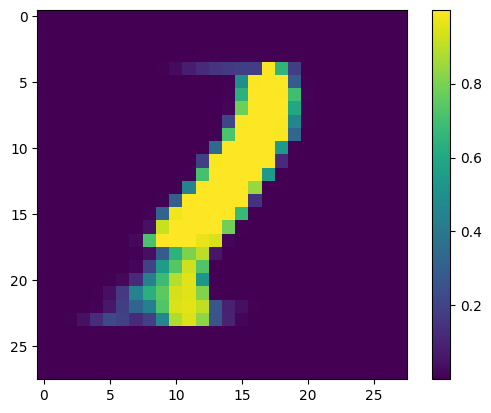

In [68]:
idx= 0
predictions = model_fn(params, inputs * jnp.array([1]*484 + [0]*300)[None])
plt.imshow(jnp.reshape(jax.nn.sigmoid(predictions[idx]), (28,28)))
plt.colorbar()

In [69]:
def sample(params, key, samples=10):
    DIM = 784
    samples = jnp.zeros((samples, DIM), dtype=jnp.int32)
    for i in range(DIM):
        key, subkey = jrandom.split(key)
        logits = model_fn(params, samples)
        prediction = jax.random.bernoulli(subkey, jax.nn.sigmoid(logits[:,i + 1]))
        samples = samples.at[:,i+1].set(prediction)
        samples = samples.astype(jnp.int32)
    return samples

In [70]:
samples = sample(params, jax.random.PRNGKey(0), samples=1)

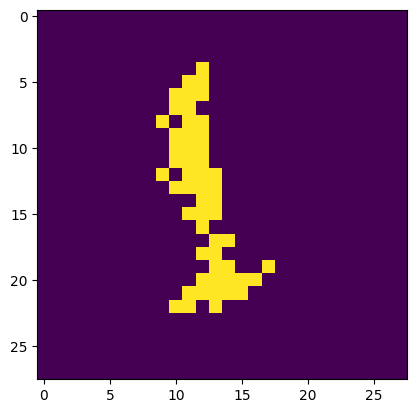

In [72]:
plt.imshow(samples[0].reshape(28,28))